# Model 2 Training - YOLOv8s (Small) - Google Colab

Train YOLOv8s model on Google Colab with GPU:

1. **Baseline** - No augmentation (on processed data)
2. **Augmented** - With on-the-fly augmentation (on processed data)

Then evaluate both models on the test set and generate comprehensive results.

**Note: Make sure `yolo_dataset.zip` is in `/content/drive/MyDrive/521_final_plroject/`**


## Step 1: Mount Google Drive


In [1]:
from google.colab import drive

drive.mount("/content/drive")
print("Drive mounted successfully!")

Mounted at /content/drive
Drive mounted successfully!


## Step 2: Check GPU


In [2]:
import torch

print("=" * 70)
print("GPU DIAGNOSIS")
print("=" * 70)
print(f"PyTorch CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"PyTorch CUDA version: {torch.version.cuda}")
    print(f"PyTorch device count: {torch.cuda.device_count()}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print("SUCCESS: GPU DETECTED!")
    device = 0
else:
    print("ERROR: NO GPU DETECTED!")
    print("Please enable GPU: Runtime -> Change runtime type -> T4 GPU")
    device = "cpu"
print(f"YOLO Device: {device}")
print("=" * 70)

GPU DIAGNOSIS
PyTorch CUDA available: True
PyTorch CUDA version: 12.6
PyTorch device count: 1
GPU Device: NVIDIA A100-SXM4-40GB
SUCCESS: GPU DETECTED!
YOLO Device: 0


## Step 3: Extract Dataset from Zip


In [3]:
# Extract dataset from Drive to Colab local storage (faster training)
zip_path = "/content/drive/MyDrive/521_final_project/yolo_dataset.zip"

print("Extracting dataset to /content/ for faster access...")
print("This may take 5-10 minutes...")

!unzip -q {zip_path} -d /content/

# Verify
!ls /content/data/processed/yolo_format/
print("\nDataset extracted to /content/data/processed/yolo_format/")

Extracting dataset to /content/ for faster access...
This may take 5-10 minutes...
classes.txt  class_mapping.json  dataset.yaml  images  labels

Dataset extracted to /content/data/processed/yolo_format/


## Step 4: Update Dataset YAML Paths


In [4]:
import yaml
from pathlib import Path

# Update dataset.yaml paths for Colab
colab_data_path = Path("/content/data/processed/yolo_format")
dataset_yaml_path = colab_data_path / "dataset.yaml"

# Load and update the dataset.yaml file
with open(dataset_yaml_path, "r") as f:
    dataset_config = yaml.safe_load(f)

# Update paths
dataset_config["path"] = str(colab_data_path)
dataset_config["train"] = "images/train"
dataset_config["val"] = "images/val"
if "test" in dataset_config and dataset_config["test"]:
    dataset_config["test"] = "images/test"

# Save the updated dataset.yaml
with open(dataset_yaml_path, "w") as f:
    yaml.safe_dump(dataset_config, f, default_flow_style=False)

print(f"Updated dataset.yaml at {dataset_yaml_path} with Colab paths")

Updated dataset.yaml at /content/data/processed/yolo_format/dataset.yaml with Colab paths


## Step 5: Install Packages


In [5]:
%pip install ultralytics -q
print('Packages installed!')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 63.5 MB/s eta 0:00:00
Packages installed!


## Step 6: Configuration


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
import yaml
import shutil
import warnings

warnings.filterwarnings("ignore")

# Set style for visualizations
plt.style.use("default")
sns.set_palette("husl")

# Model Configuration
MODEL_VARIANT = "yolov8s.pt"
MODEL_NAME = "YOLOv8s"

CONFIG = {
    "epochs": 50,
    "batch_size": 16,
    "img_size": 640,
    "patience": 10,
    "device": device,  # Use GPU from Step 2
}

# Augmentation settings (on-the-fly)
AUGMENTATION_CONFIG = {
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.5,
    "mosaic": 1.0,
}

# Paths - Data from /content/, Results to Drive
YOLO_DIR = Path("/content/data/processed/yolo_format")
DATASET_YAML = YOLO_DIR / "dataset.yaml"
DATASET_YAML_BACKUP = YOLO_DIR / "dataset.yaml.backup"

# Save results to Drive (will persist after Colab disconnects)
DRIVE_PROJECT = Path("/content/drive/MyDrive/521_final_plroject")
RESULTS_DIR = DRIVE_PROJECT / "results/models_output"
VIZ_DIR = DRIVE_PROJECT / "results/visualizations/training"
TEST_RESULTS_DIR = DRIVE_PROJECT / "results/test_evaluation"
TEST_VIZ_DIR = DRIVE_PROJECT / "results/visualizations/test_evaluation"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)
TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
TEST_VIZ_DIR.mkdir(parents=True, exist_ok=True)

# Verify dataset.yaml exists
if not DATASET_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found at {DATASET_YAML}")

print("Configuration:")
print(f"  Model: {MODEL_NAME} ({MODEL_VARIANT})")
print(f'  Epochs: {CONFIG["epochs"]}')
print(f'  Batch Size: {CONFIG["batch_size"]}')
print(f'  Device: {CONFIG["device"]}')
print(f"  Dataset: {DATASET_YAML}")
print(f"  Results save to Drive: {RESULTS_DIR}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Configuration:
  Model: YOLOv8s (yolov8s.pt)
  Epochs: 50
  Batch Size: 16
  Device: 0
  Dataset: /content/data/processed/yolo_format/dataset.yaml
  Results save to Drive: /content/drive/MyDrive/521_final_plroject/results/models_output


## Step 7: Verify Dataset


In [7]:
with open(DATASET_YAML, "r") as f:
    dataset_config = yaml.safe_load(f)

train_count = len(list((YOLO_DIR / "images/train").glob("*.jpg")))
val_count = len(list((YOLO_DIR / "images/val").glob("*.jpg")))
test_count = len(list((YOLO_DIR / "images/test").glob("*.jpg")))

print("Dataset Information:")
print(f'  Classes: {dataset_config["nc"]}')
print(f"  Train: {train_count:,} images")
print(f"  Val: {val_count:,} images")
print(f"  Test: {test_count:,} images")

Dataset Information:
  Classes: 195
  Train: 32,979 images
  Val: 10,522 images
  Test: 5,981 images


## Step 8: Train Baseline Model (No Augmentation)


In [8]:
print("=" * 70)
print(f"TRAINING {MODEL_NAME} BASELINE MODEL (NO AUGMENTATION)")
print("=" * 70)

model_baseline = YOLO(MODEL_VARIANT)

results_baseline = model_baseline.train(
    data=str(DATASET_YAML),
    epochs=CONFIG["epochs"],
    imgsz=CONFIG["img_size"],
    batch=CONFIG["batch_size"],
    device=CONFIG["device"],
    patience=CONFIG["patience"],
    project=str(RESULTS_DIR),
    name=f"{MODEL_NAME.lower()}_baseline",
    # Disable all augmentation
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    fliplr=0.0,
    mosaic=0.0,
    save=True,
    plots=True,
    verbose=True,
)

# Evaluate on validation set
metrics_baseline = model_baseline.val()

print(f"\n{MODEL_NAME} Baseline Training Complete!")
print(f"  mAP@0.5: {metrics_baseline.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {metrics_baseline.box.map:.4f}")
print(f"  Precision: {metrics_baseline.box.mp:.4f}")
print(f"  Recall: {metrics_baseline.box.mr:.4f}")
print(f"  Best model: {RESULTS_DIR}/{MODEL_NAME.lower()}_baseline/weights/best.pt")

TRAINING YOLOv8s BASELINE MODEL (NO AUGMENTATION)
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=False, name=yolov8s_baseline3, nbs=64, nms=False, opset=None, optimize=F

## Step 9: Train Augmented Model (On-the-Fly Augmentation)


In [9]:
print("=" * 70)
print(f"TRAINING {MODEL_NAME} WITH AUGMENTATION (ON-THE-FLY)")
print("=" * 70)

model_augmented = YOLO(MODEL_VARIANT)

results_augmented = model_augmented.train(
    data=str(DATASET_YAML),
    epochs=CONFIG["epochs"],
    imgsz=CONFIG["img_size"],
    batch=CONFIG["batch_size"],
    device=CONFIG["device"],
    patience=CONFIG["patience"],
    project=str(RESULTS_DIR),
    name=f"{MODEL_NAME.lower()}_augmented",
    # Enable augmentation
    hsv_h=AUGMENTATION_CONFIG["hsv_h"],
    hsv_s=AUGMENTATION_CONFIG["hsv_s"],
    hsv_v=AUGMENTATION_CONFIG["hsv_v"],
    translate=AUGMENTATION_CONFIG["translate"],
    scale=AUGMENTATION_CONFIG["scale"],
    fliplr=AUGMENTATION_CONFIG["fliplr"],
    mosaic=AUGMENTATION_CONFIG["mosaic"],
    save=True,
    plots=True,
    verbose=True,
)

# Evaluate on validation set
metrics_augmented = model_augmented.val()

print(f"\n{MODEL_NAME} Augmented Training Complete!")
print(f"  mAP@0.5: {metrics_augmented.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {metrics_augmented.box.map:.4f}")
print(f"  Precision: {metrics_augmented.box.mp:.4f}")
print(f"  Recall: {metrics_augmented.box.mr:.4f}")
print(f"  Best model: {RESULTS_DIR}/{MODEL_NAME.lower()}_augmented/weights/best.pt")

TRAINING YOLOv8s WITH AUGMENTATION (ON-THE-FLY)
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/processed/yolo_format/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8s_augmented, nbs=64, nms=False, opset=None, optimize=F

## Step 10: Validation Set Performance Comparison


In [10]:
# Create comparison DataFrame
comparison_val = pd.DataFrame(
    {
        "Model": ["Baseline (Val)", "Augmented (Val)"],
        "mAP@0.5": [metrics_baseline.box.map50, metrics_augmented.box.map50],
        "mAP@0.5:0.95": [metrics_baseline.box.map, metrics_augmented.box.map],
        "Precision": [metrics_baseline.box.mp, metrics_augmented.box.mp],
        "Recall": [metrics_baseline.box.mr, metrics_augmented.box.mr],
    }
)

print("=" * 70)
print(f"{MODEL_NAME} VALIDATION SET PERFORMANCE COMPARISON")
print("=" * 70)
print(comparison_val.to_string(index=False))

improvement_map50 = (
    (metrics_augmented.box.map50 - metrics_baseline.box.map50)
    / metrics_baseline.box.map50
    * 100
)
improvement_map = (
    (metrics_augmented.box.map - metrics_baseline.box.map)
    / metrics_baseline.box.map
    * 100
)

print(f"\nImprovement (mAP@0.5): {improvement_map50:+.2f}%")
print(f"Improvement (mAP@0.5:0.95): {improvement_map:+.2f}%")

# Save comparison
comparison_val.to_csv(
    RESULTS_DIR / f"{MODEL_NAME.lower()}_validation_comparison.csv", index=False
)
print(f"\nSaved to: {RESULTS_DIR}/{MODEL_NAME.lower()}_validation_comparison.csv")

YOLOv8s VALIDATION SET PERFORMANCE COMPARISON
          Model  mAP@0.5  mAP@0.5:0.95  Precision  Recall
 Baseline (Val) 0.444645      0.418860   0.481822 0.42243
Augmented (Val) 0.658581      0.624796   0.643377 0.62925

Improvement (mAP@0.5): +48.11%
Improvement (mAP@0.5:0.95): +49.17%

Saved to: /content/drive/MyDrive/521_final_plroject/results/models_output/yolov8s_validation_comparison.csv


## Step 11: Plot Training Curves


Saved to: /content/drive/MyDrive/521_final_plroject/results/visualizations/training/yolov8s_training_curves.png


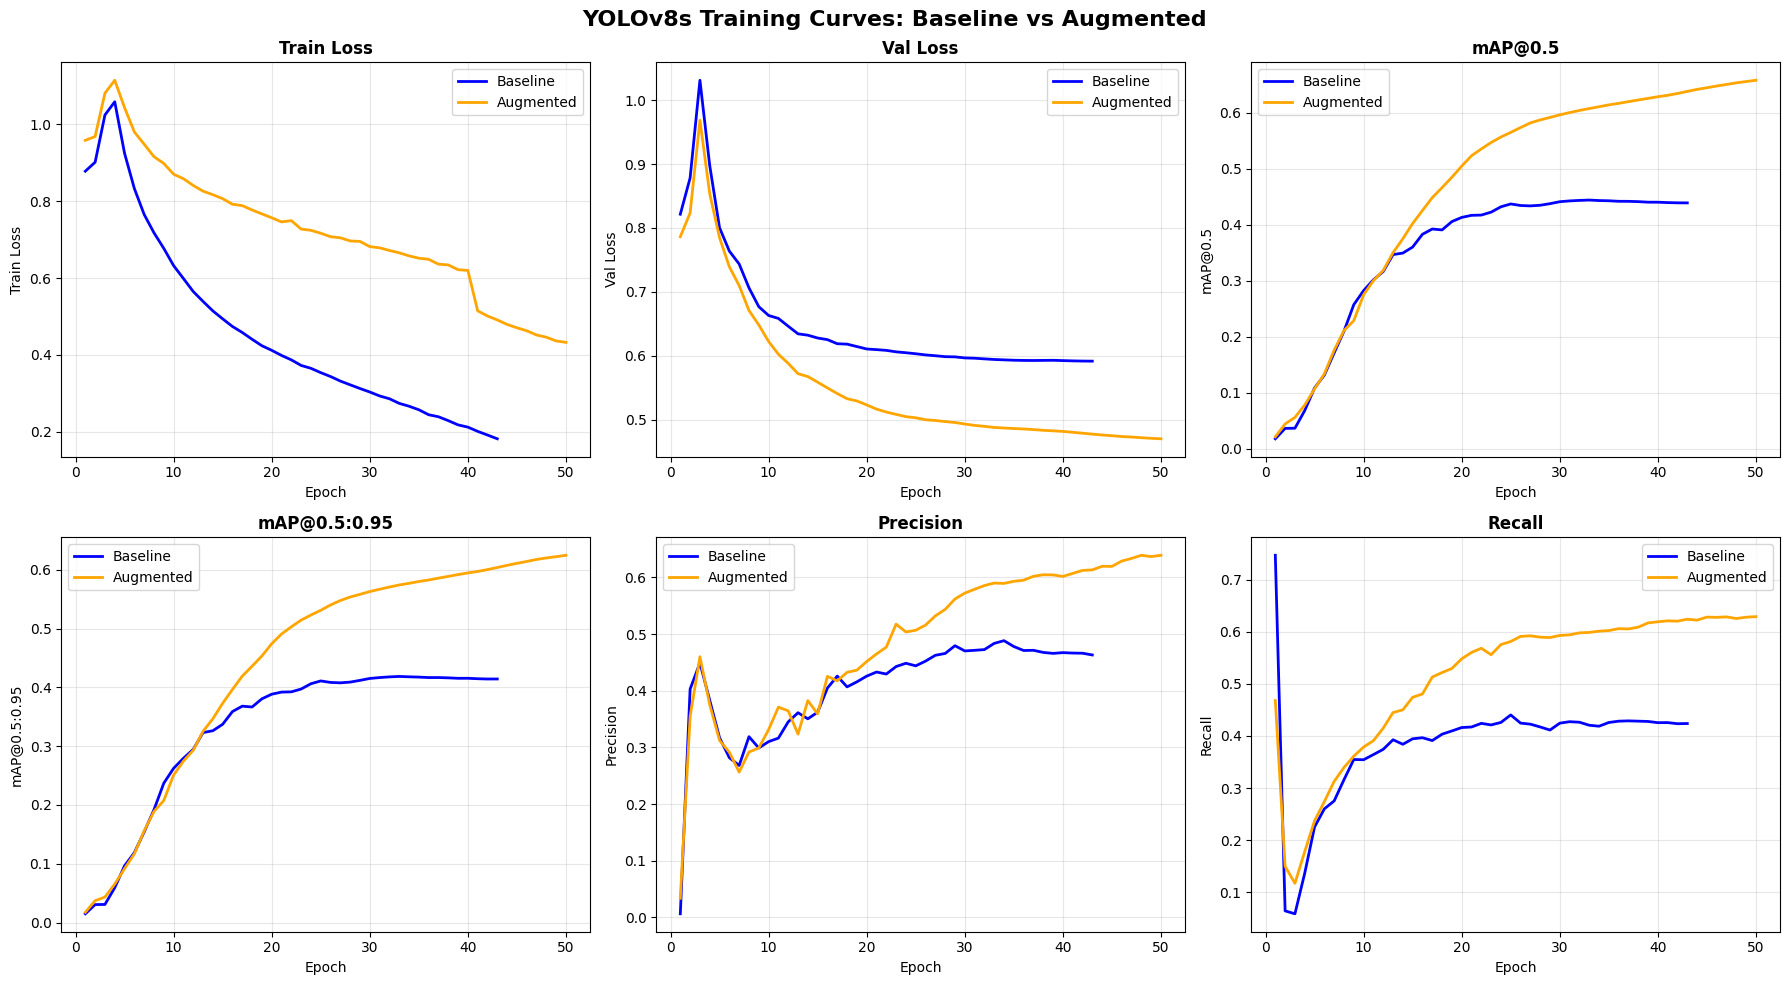

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load training results CSV
baseline_hist = pd.read_csv(RESULTS_DIR / f"{MODEL_NAME.lower()}_baseline3/results.csv")
augmented_hist = pd.read_csv(
    RESULTS_DIR / f"{MODEL_NAME.lower()}_augmented/results.csv"
)

baseline_hist.columns = baseline_hist.columns.str.strip()
augmented_hist.columns = augmented_hist.columns.str.strip()

# Create comprehensive training curves comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f"{MODEL_NAME} Training Curves: Baseline vs Augmented",
    fontsize=16,
    fontweight="bold",
)

metrics_to_plot = [
    ("train/box_loss", "Train Loss", axes[0, 0]),
    ("val/box_loss", "Val Loss", axes[0, 1]),
    ("metrics/mAP50(B)", "mAP@0.5", axes[0, 2]),
    ("metrics/mAP50-95(B)", "mAP@0.5:0.95", axes[1, 0]),
    ("metrics/precision(B)", "Precision", axes[1, 1]),
    ("metrics/recall(B)", "Recall", axes[1, 2]),
]

for metric_col, title, ax in metrics_to_plot:
    if metric_col in baseline_hist.columns:
        ax.plot(
            baseline_hist["epoch"],
            baseline_hist[metric_col],
            label="Baseline",
            lw=2,
            color="blue",
        )
    if metric_col in augmented_hist.columns:
        ax.plot(
            augmented_hist["epoch"],
            augmented_hist[metric_col],
            label="Augmented",
            lw=2,
            color="orange",
        )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(title, fontsize=10)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    VIZ_DIR / f"{MODEL_NAME.lower()}_training_curves.png", dpi=300, bbox_inches="tight"
)
plt.savefig(VIZ_DIR / f"{MODEL_NAME.lower()}_training_curves.pdf", bbox_inches="tight")
print(f"Saved to: {VIZ_DIR}/{MODEL_NAME.lower()}_training_curves.png")
plt.show()

## Step 12: Prepare Dataset YAML for Test Evaluation


In [15]:
# Load original dataset config
with open(DATASET_YAML, "r") as f:
    dataset_config = yaml.safe_load(f)

# Backup original dataset.yaml
if DATASET_YAML_BACKUP.exists():
    shutil.copy(str(DATASET_YAML_BACKUP), str(DATASET_YAML))
else:
    shutil.copy(str(DATASET_YAML), str(DATASET_YAML_BACKUP))

# Modify dataset.yaml to use test split for validation
original_val = dataset_config.get("val", "images/val")
original_test = dataset_config.get("test", "images/test")

test_dataset_config = dataset_config.copy()
test_dataset_config["val"] = original_test  # Use test as val for evaluation

# Save modified config
with open(DATASET_YAML, "w") as f:
    yaml.safe_dump(test_dataset_config, f, default_flow_style=False)

print("Dataset YAML temporarily modified to use test split for evaluation")
print(f"  Original val: {original_val}")
print(f"  Now using as val (test set): {original_test}")

Dataset YAML temporarily modified to use test split for evaluation
  Original val: images/test
  Now using as val (test set): images/test


## Step 13: Evaluate Baseline Model on Test Set


In [23]:
print("=" * 70)
print(f"EVALUATING {MODEL_NAME} BASELINE MODEL ON TEST SET")
print("=" * 70)

# Load baseline model
baseline_model_path = (
    RESULTS_DIR / f"{MODEL_NAME.lower()}_baseline3" / "weights" / "best.pt"
)
model_baseline_test = YOLO(str(baseline_model_path))

# Evaluate on test set
test_metrics_baseline = model_baseline_test.val(
    data=str(DATASET_YAML),
    imgsz=640,
    conf=0.25,
    iou=0.7,
    save_json=True,
    save_hybrid=False,
    plots=True,
    project=str(TEST_RESULTS_DIR),
    name=f"{MODEL_NAME.lower()}_baseline_test",
)

print(f"\n{MODEL_NAME} Baseline Test Set Performance:")
print(f"  mAP@0.5: {test_metrics_baseline.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {test_metrics_baseline.box.map:.4f}")
print(f"  Precision: {test_metrics_baseline.box.mp:.4f}")
print(f"  Recall: {test_metrics_baseline.box.mr:.4f}")
print(f"\nResults saved to: {TEST_RESULTS_DIR}/{MODEL_NAME.lower()}_baseline_test/")

EVALUATING YOLOv8s BASELINE MODEL ON TEST SET
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 11,201,049 parameters, 0 gradients, 28.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3337.4±1507.0 MB/s, size: 1033.2 KB)
val: Scanning /content/data/processed/yolo_format/labels/val.cache... 10522 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 10522/10522 15.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 658/658 14.1it/s 46.6s
                   all      10522      10522      0.523      0.382      0.459       0.44
               707-320         33         33      0.882      0.455       0.66      0.639
               727-200         34         34      0.786      0.647      0.737      0.701
               737-200         33         33      0.842      0

## Step 14: Evaluate Augmented Model on Test Set


In [17]:
print("=" * 70)
print(f"EVALUATING {MODEL_NAME} AUGMENTED MODEL ON TEST SET")
print("=" * 70)

# Load augmented model
augmented_model_path = (
    RESULTS_DIR / f"{MODEL_NAME.lower()}_augmented" / "weights" / "best.pt"
)
model_augmented_test = YOLO(str(augmented_model_path))

# Evaluate on test set
test_metrics_augmented = model_augmented_test.val(
    data=str(DATASET_YAML),
    imgsz=640,
    conf=0.25,
    iou=0.7,
    save_json=True,
    save_hybrid=False,
    plots=True,
    project=str(TEST_RESULTS_DIR),
    name=f"{MODEL_NAME.lower()}_augmented_test",
)

print(f"\n{MODEL_NAME} Augmented Test Set Performance:")
print(f"  mAP@0.5: {test_metrics_augmented.box.map50:.4f}")
print(f"  mAP@0.5:0.95: {test_metrics_augmented.box.map:.4f}")
print(f"  Precision: {test_metrics_augmented.box.mp:.4f}")
print(f"  Recall: {test_metrics_augmented.box.mr:.4f}")
print(f"\nResults saved to: {TEST_RESULTS_DIR}/{MODEL_NAME.lower()}_augmented_test/")

EVALUATING YOLOv8s AUGMENTED MODEL ON TEST SET
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in the future.
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 72 layers, 11,201,049 parameters, 0 gradients, 28.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2459.6±545.9 MB/s, size: 1050.2 KB)
val: Scanning /content/data/processed/yolo_format/labels/test.cache... 5981 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5981/5981 10.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 374/374 12.5it/s 30.0s
                   all       5981       5981      0.649      0.636      0.671      0.646
               707-320         33         33      0.772          1      0.988      0.942
               727-200         33         33      0.936      0.884      0.939       0.89
               737-200         34         34      0.903      0.8

## Step 15: Restore Original Dataset YAML


In [18]:
# Restore original dataset.yaml
shutil.copy(str(DATASET_YAML_BACKUP), str(DATASET_YAML))
print("Original dataset.yaml restored")

Original dataset.yaml restored


## Step 16: Test Set Performance Comparison


In [19]:
# Create comparison DataFrame
comparison_test = pd.DataFrame(
    {
        "Model": ["Baseline (Test)", "Augmented (Test)"],
        "mAP@0.5": [test_metrics_baseline.box.map50, test_metrics_augmented.box.map50],
        "mAP@0.5:0.95": [test_metrics_baseline.box.map, test_metrics_augmented.box.map],
        "Precision": [test_metrics_baseline.box.mp, test_metrics_augmented.box.mp],
        "Recall": [test_metrics_baseline.box.mr, test_metrics_augmented.box.mr],
    }
)

print("=" * 70)
print(f"{MODEL_NAME} TEST SET PERFORMANCE COMPARISON")
print("=" * 70)
print(comparison_test.to_string(index=False))

# Calculate improvement
test_improvement_map50 = (
    (test_metrics_augmented.box.map50 - test_metrics_baseline.box.map50)
    / test_metrics_baseline.box.map50
    * 100
)
test_improvement_map = (
    (test_metrics_augmented.box.map - test_metrics_baseline.box.map)
    / test_metrics_baseline.box.map
    * 100
)

print(f"\nTest Set Improvement (mAP@0.5): {test_improvement_map50:+.2f}%")
print(f"Test Set Improvement (mAP@0.5:0.95): {test_improvement_map:+.2f}%")

# Save comparison
comparison_test.to_csv(
    TEST_RESULTS_DIR / f"{MODEL_NAME.lower()}_test_comparison.csv", index=False
)
print(f"\nSaved to: {TEST_RESULTS_DIR}/{MODEL_NAME.lower()}_test_comparison.csv")

YOLOv8s TEST SET PERFORMANCE COMPARISON
           Model  mAP@0.5  mAP@0.5:0.95  Precision   Recall
 Baseline (Test) 0.450686      0.430976   0.503993 0.383540
Augmented (Test) 0.671151      0.646036   0.648791 0.636069

Test Set Improvement (mAP@0.5): +48.92%
Test Set Improvement (mAP@0.5:0.95): +49.90%

Saved to: /content/drive/MyDrive/521_final_plroject/results/test_evaluation/yolov8s_test_comparison.csv


## Step 17: Visualize Test Set Performance


Saved to: /content/drive/MyDrive/521_final_plroject/results/visualizations/test_evaluation/yolov8s_test_performance_comparison.png


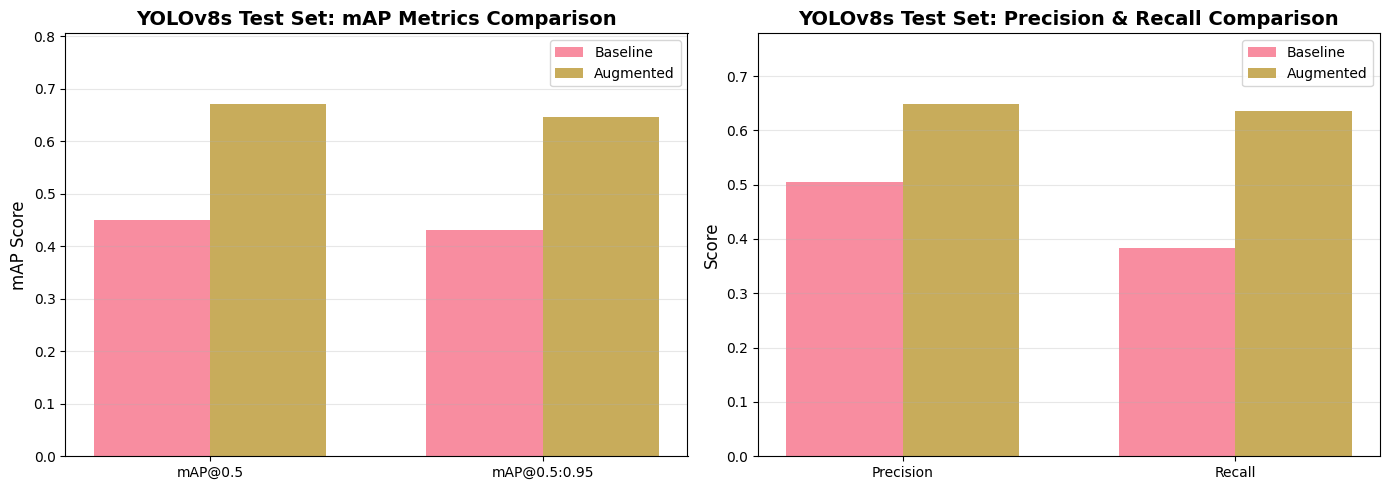

In [20]:
# Create visualization comparing test set performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for mAP metrics
metrics_to_plot = ["mAP@0.5", "mAP@0.5:0.95"]
x = np.arange(len(metrics_to_plot))
width = 0.35

baseline_values = [test_metrics_baseline.box.map50, test_metrics_baseline.box.map]
augmented_values = [test_metrics_augmented.box.map50, test_metrics_augmented.box.map]

axes[0].bar(x - width / 2, baseline_values, width, label="Baseline", alpha=0.8)
axes[0].bar(x + width / 2, augmented_values, width, label="Augmented", alpha=0.8)
axes[0].set_ylabel("mAP Score", fontsize=12)
axes[0].set_title(
    f"{MODEL_NAME} Test Set: mAP Metrics Comparison", fontsize=14, fontweight="bold"
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")
axes[0].set_ylim([0, max(max(baseline_values), max(augmented_values)) * 1.2])

# Bar plot for Precision and Recall
pr_metrics = ["Precision", "Recall"]
x2 = np.arange(len(pr_metrics))

baseline_pr = [test_metrics_baseline.box.mp, test_metrics_baseline.box.mr]
augmented_pr = [test_metrics_augmented.box.mp, test_metrics_augmented.box.mr]

axes[1].bar(x2 - width / 2, baseline_pr, width, label="Baseline", alpha=0.8)
axes[1].bar(x2 + width / 2, augmented_pr, width, label="Augmented", alpha=0.8)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title(
    f"{MODEL_NAME} Test Set: Precision & Recall Comparison",
    fontsize=14,
    fontweight="bold",
)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(pr_metrics)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")
axes[1].set_ylim([0, max(max(baseline_pr), max(augmented_pr)) * 1.2])

plt.tight_layout()
plt.savefig(
    TEST_VIZ_DIR / f"{MODEL_NAME.lower()}_test_performance_comparison.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    TEST_VIZ_DIR / f"{MODEL_NAME.lower()}_test_performance_comparison.pdf",
    bbox_inches="tight",
)
print(f"Saved to: {TEST_VIZ_DIR}/{MODEL_NAME.lower()}_test_performance_comparison.png")
plt.show()

## Step 18: Summary and Model Locations


In [24]:
print("=" * 70)
print(f"{MODEL_NAME} TRAINING AND EVALUATION COMPLETE")
print("=" * 70)

print("\nVALIDATION SET PERFORMANCE:")
print(f"  Baseline - mAP@0.5: {metrics_baseline.box.map50:.4f}")
print(f"  Augmented - mAP@0.5: {metrics_augmented.box.map50:.4f}")

print("\nTEST SET PERFORMANCE:")
print(f"  Baseline - mAP@0.5: {test_metrics_baseline.box.map50:.4f}")
print(f"  Augmented - mAP@0.5: {test_metrics_augmented.box.map50:.4f}")

print("\nBEST MODEL (Test Set):")
if test_metrics_augmented.box.map50 > test_metrics_baseline.box.map50:
    print(f"  Augmented Model performs better!")
    print(f"  mAP@0.5: {test_metrics_augmented.box.map50:.4f}")
    best_model_path = (
        RESULTS_DIR / f"{MODEL_NAME.lower()}_augmented" / "weights" / "best.pt"
    )
else:
    print(f"  Baseline Model performs better!")
    print(f"  mAP@0.5: {test_metrics_baseline.box.map50:.4f}")
    best_model_path = (
        RESULTS_DIR / f"{MODEL_NAME.lower()}_baseline3" / "weights" / "best.pt"
    )

print("\nMODEL LOCATIONS (for deployment):")
print(f"  Baseline: {RESULTS_DIR}/{MODEL_NAME.lower()}_baseline3/weights/best.pt")
print(f"  Augmented: {RESULTS_DIR}/{MODEL_NAME.lower()}_augmented/weights/best.pt")
print(f"  Best Model: {best_model_path}")

print("\nOUTPUTS SAVED:")
print(
    f"  Validation Comparison: {RESULTS_DIR}/{MODEL_NAME.lower()}_validation_comparison.csv"
)
print(f"  Test Comparison: {TEST_RESULTS_DIR}/{MODEL_NAME.lower()}_test_comparison.csv")
print(f"  Training Curves: {VIZ_DIR}/{MODEL_NAME.lower()}_training_curves.png")
print(
    f"  Test Performance: {TEST_VIZ_DIR}/{MODEL_NAME.lower()}_test_performance_comparison.png"
)
print("=" * 70)

YOLOv8s TRAINING AND EVALUATION COMPLETE

VALIDATION SET PERFORMANCE:
  Baseline - mAP@0.5: 0.4446
  Augmented - mAP@0.5: 0.6586

TEST SET PERFORMANCE:
  Baseline - mAP@0.5: 0.4595
  Augmented - mAP@0.5: 0.6712

BEST MODEL (Test Set):
  Augmented Model performs better!
  mAP@0.5: 0.6712

MODEL LOCATIONS (for deployment):
  Baseline: /content/drive/MyDrive/521_final_plroject/results/models_output/yolov8s_baseline3/weights/best.pt
  Augmented: /content/drive/MyDrive/521_final_plroject/results/models_output/yolov8s_augmented/weights/best.pt
  Best Model: /content/drive/MyDrive/521_final_plroject/results/models_output/yolov8s_augmented/weights/best.pt

OUTPUTS SAVED:
  Validation Comparison: /content/drive/MyDrive/521_final_plroject/results/models_output/yolov8s_validation_comparison.csv
  Test Comparison: /content/drive/MyDrive/521_final_plroject/results/test_evaluation/yolov8s_test_comparison.csv
  Training Curves: /content/drive/MyDrive/521_final_plroject/results/visualizations/training